### STARVED V FED

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window60.csv')


df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'})

palette = {'starved': "#F3D00E", 'fed': '#0B5D2A'}

df = df.sort_values(['file', 'track_id', 'rel_frame'])

metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['file', 'track_id', 'role', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

first_interaction = first_interaction[first_interaction['rel_frame'] < 0]


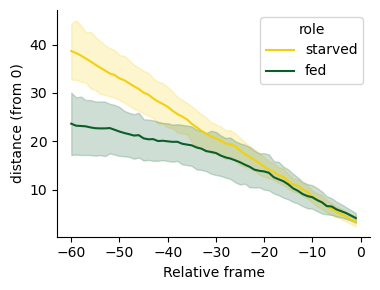

In [12]:
fig, ax = plt.subplots(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='role',
    hue_order=['starved', 'fed'],
    palette=palette,
    errorbar=('ci', 95),
    ax=ax,
)

ax.set_xlabel('Relative frame')
ax.set_ylabel('distance (from 0)')
# ax.axvline(0, color='black', linestyle='--', linewidth=1)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/distance_from_0_precontact.pdf', format='pdf')
plt.show()


role
fed        19.523045
starved    35.335130
dtype: float64
Wilcoxon paired test, distance closed -60 to -1, starved vs fed: W=5, p=0.00122


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_12171/2159550649.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_12171/2159550649.py:37: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


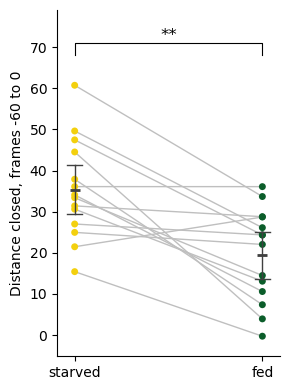

In [13]:
distance_closed = (
    first_interaction[first_interaction['rel_frame'].isin([-60, -1])]
    .pivot_table(index=['file', 'role'], columns='rel_frame', values='distance_from_0')
)

distance_closed['closed_distance'] = distance_closed[-60] - distance_closed[-1]
closed_by_role = distance_closed['closed_distance'].unstack().dropna(subset=['starved', 'fed'])

stat, p = wilcoxon(closed_by_role['starved'], closed_by_role['fed'])
print(closed_by_role.mean())
print(f"Wilcoxon paired test, distance closed -60 to -1, starved vs fed: W={stat:.3g}, p={p:.3g}")

plot_data = closed_by_role.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='closed_distance',
)

fig, ax = plt.subplots(figsize=(3, 4))

for _, row in closed_by_role.iterrows():
    ax.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=plot_data,
    x='role',
    y='closed_distance',
    order=['starved', 'fed'],
    palette=palette,
    size=5,
    jitter=False,
    ax=ax,
    zorder=2,
)

sns.pointplot(
    data=plot_data,
    x='role',
    y='closed_distance',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False,
    ax=ax,
)

stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
y_min = closed_by_role.min().min()
y_max = closed_by_role.max().max()
y_range = y_max - y_min if y_max > y_min else 1
bracket_y = y_max + 0.12 * y_range
bracket_h = 0.05 * y_range

ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + bracket_h, bracket_y + bracket_h, bracket_y], color='black', linewidth=0.8)
ax.text(0.5, bracket_y + bracket_h, stars, ha='center', va='bottom', fontsize=12)

ax.set_xlabel('')
ax.set_ylabel('Distance closed, frames -60 to 0')
ax.set_ylim(y_min - 0.08 * y_range, bracket_y + 0.18 * y_range)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/distance_from_0_precontact_mean.pdf', format='pdf')
plt.show()


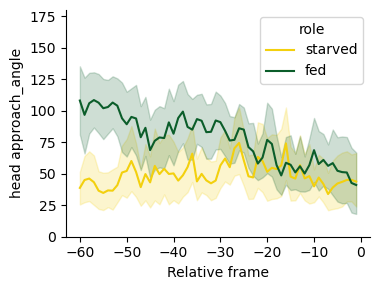

In [16]:
fig, ax = plt.subplots(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='role',
    hue_order=['starved', 'fed'],
    palette=palette,
    errorbar=('ci', 95),
    ax=ax,
)

ax.set_xlabel('Relative frame')
ax.set_ylabel('head approach_angle')
plt.ylim(0, 180)
# ax.axvline(0, color='black', linestyle='--', linewidth=1)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/approach_angle_head.pdf', format='pdf')
plt.show()


role
fed        77.488453
starved    49.349232
dtype: float64
Wilcoxon paired test, mean approach angle -60 to 0, starved vs fed: W=11, p=0.00671


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_12171/3491214893.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_12171/3491214893.py:37: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


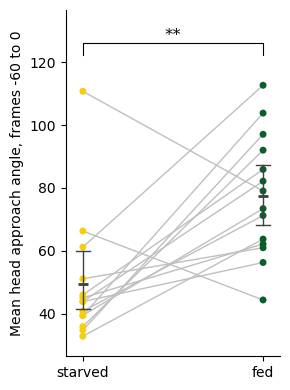

In [15]:
angle_pre = (
    first_interaction[first_interaction['rel_frame'].between(-60, 0)]
    .groupby(['file', 'role'])['approach_angle_head']
    .mean()
    .unstack()
    .dropna(subset=['starved', 'fed'])
)

stat, p = wilcoxon(angle_pre['starved'], angle_pre['fed'])
print(angle_pre.mean())
print(f"Wilcoxon paired test, mean approach angle -60 to 0, starved vs fed: W={stat:.3g}, p={p:.3g}")

plot_data = angle_pre.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='approach_angle_head',
)

fig, ax = plt.subplots(figsize=(3, 4))

for _, row in angle_pre.iterrows():
    ax.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=plot_data,
    x='role',
    y='approach_angle_head',
    order=['starved', 'fed'],
    palette=palette,
    size=5,
    jitter=False,
    ax=ax,
    zorder=2,
)

sns.pointplot(
    data=plot_data,
    x='role',
    y='approach_angle_head',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False,
    ax=ax,
)

stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
y_min = angle_pre.min().min()
y_max = angle_pre.max().max()
y_range = y_max - y_min if y_max > y_min else 1
bracket_y = y_max + 0.12 * y_range
bracket_h = 0.05 * y_range

ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + bracket_h, bracket_y + bracket_h, bracket_y], color='black', linewidth=0.8)
ax.text(0.5, bracket_y + bracket_h, stars, ha='center', va='bottom', fontsize=12)

ax.set_xlabel('')
ax.set_ylabel('Mean head approach angle, frames -60 to 0')
ax.set_ylim(y_min - 0.08 * y_range, bracket_y + 0.18 * y_range)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/approach_angle_head_mean.pdf', format='pdf')
plt.show()
